In [ ]:
# if you wanna download the dataset
"""
import os

# Set folder
os.environ["KAGGLEHUB_CACHE_DIR"] = "/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/max_plank_weather/all_models_training"

import kagglehub

path = kagglehub.dataset_download("arashnic/max-planck-weather-dataset")
print("Path dataset:", path)
"""

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from source_code.dataset_transform import load_and_preprocess_data
import pandas as pd

In [3]:
# --- Step A: Data Loading ---
(
    df_1,
    df_all,
    hist_exog_cols_1,
    time_exog_cols,
    target_col_1,
    all_target,
) = load_and_preprocess_data('/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/max_planck_weather_ts.csv')

1. Read and process the dataset...
✅ pra-pemrosesan selesai:
   - df_1  (1 target)   : (70129, 20) | unique_id: 1
   - df_all (14 target)  : (981806, 7) | unique_id: 14


In [4]:
# --- Step B: Train-Test Split (Long Format) ---
HORIZON = 24  # Predict 24 hours in the future
INPUT_SIZE = 48  # Lookback 48 hours in the past

NUM_TIMESTAMPS = 10000  # Total timestamp that is used
TEST_TIMESTAMPS = 2000  # Timestamp for test

# =====================================================================
# SCENARIO 1: DATASET 1 TARGET (Temperature T)
# =====================================================================
NUM_TARGETS_1 = len(target_col_1)  # 1 Target

# Take the last 10000 timestamps based on the 'ds' column
unique_ds_1 = df_1['ds'].unique()[-NUM_TIMESTAMPS:]
df_sample_1 = df_1[df_1['ds'].isin(unique_ds_1)].reset_index(drop=True)

# Data Splitting
last_train_ds_1 = unique_ds_1[-TEST_TIMESTAMPS]
train_df_1 = df_sample_1[df_sample_1['ds'] < last_train_ds_1].copy()
test_df_1 = df_sample_1[df_sample_1['ds'] >= last_train_ds_1].copy()

print(
    f'Dataset Information: 1 Target:\n'
    f'- Number of Target Features  : {NUM_TARGETS_1} feature ({target_col_1[0]})\n'
    f'- Timestep Train Data  : {len(train_df_1) // NUM_TARGETS_1} rows\n'
    f'- Timestep Test Data   : {len(test_df_1) // NUM_TARGETS_1} rows\n'
)

# =====================================================================
# SCENARIO 2: ALL TARGETS DATASET (14 Weather Features)
# =====================================================================
NUM_TARGETS_ALL = len(all_target)  # 14 Targets

# Retrieve the last 10,000 timestamps based on the 'ds' column for ALL unique_ids.
unique_ds_all = df_all['ds'].unique()[-NUM_TIMESTAMPS:]
df_sample_all = df_all[df_all['ds'].isin(unique_ds_all)].reset_index(
    drop=True
)

# Data Splitting
last_train_ds_all = unique_ds_all[-TEST_TIMESTAMPS]
train_df_all = df_sample_all[df_sample_all['ds'] < last_train_ds_all].copy()
test_df_all = df_sample_all[df_sample_all['ds'] >= last_train_ds_all].copy()

print(
    f'All Target Dataset Information:\n'
    f'- Number of Target Features  : {NUM_TARGETS_ALL} feature\n'
    f'- Timestep Train Data  : {len(train_df_all) // NUM_TARGETS_ALL} row per feature\n'
    f'- Timestep Test Data   : {len(test_df_all) // NUM_TARGETS_ALL} row per feature'
)

Dataset Information: 1 Target:
- Number of Target Features  : 1 feature (T (degC))
- Timestep Train Data  : 8000 rows
- Timestep Test Data   : 2000 rows

All Target Dataset Information:
- Number of Target Features  : 14 feature
- Timestep Train Data  : 8000 row per feature
- Timestep Test Data   : 2000 row per feature


# **Experiment 1: Single-Target Benchmark (Focus on 1 Target: Temperature)**

In [5]:
import os
from neuralforecast import NeuralForecast
from neuralforecast.models import GRU, DLinear, NHITS, PatchTST, iTransformer

# 1. Model Initialization for Experiment 1 (Dataset 1 Target)
models_exp1 = [
    iTransformer(
        h=HORIZON,
        input_size=INPUT_SIZE,
        n_series=1,
        #futr_exog_list=time_exog_cols,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    PatchTST(
        h=HORIZON,
        input_size=INPUT_SIZE,
        n_series=1,
        #futr_exog_list=time_exog_cols,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    DLinear(
        h=HORIZON,
        input_size=INPUT_SIZE,
        #hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    NHITS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    GRU(
        h=HORIZON,
        input_size=INPUT_SIZE,
        hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
]

# 2. Fit and Save Experimental Model 1
nf_exp1 = NeuralForecast(models=models_exp1, freq='h')
print('=== Experiment Training 1 (1 Target) ===')
VAL_SIZE = 24
nf_exp1.fit(df=train_df_1, val_size=VAL_SIZE)

path_exp1 = '/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/max_plank_weather/all_models_training/models_exp1'
nf_exp1.save(path=path_exp1, overwrite=True)

# 3. Predict / Cross Validation
cv_exp1 = nf_exp1.cross_validation(
    df=df_sample_1,
    n_windows=TEST_TIMESTAMPS // HORIZON,
    val_size=VAL_SIZE,
    use_fitted=True,
)

/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-24 00:56:03,783	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-08-24 00:56:05,153	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type                   | Params | Mode 
-----------------------------------------------------------------------
0 | loss                | MAE                    | 0   

=== Experiment Training 1 (1 Target) ===
Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/myenv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 349: 100%|██████████| 1/1 [00:00<00:00,  8.04it/s, v_num=20, train_loss_step=0.926, train_loss_epoch=0.926, valid_loss=0.608]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 418 K  | train
------------------------------------------------------------------
418 K     Trainable params
3         Non-trainable params
418 K     Total params
1.675     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


...


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 232.50it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 51.54it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 15.57it/s]


# **Experiment 2: Optimal Capacity Benchmark (Multivariate vs Exogenous)**

In [6]:
# 1. Multivariate Model (iTransformer & PatchTST predict 14 features)
models_multi = [
    iTransformer(
        h=HORIZON,
        input_size=INPUT_SIZE,
        n_series=14,
        #futr_exog_list=time_exog_cols,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    PatchTST(
        h=HORIZON,
        input_size=INPUT_SIZE,
        n_series=14,
        #futr_exog_list=time_exog_cols,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
]

# 2. Univariate Models with Exogenous Variables (DLinear, NHiTS, GRU)
models_exog = [
    DLinear(
        h=HORIZON,
        input_size=INPUT_SIZE,
        #hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    NHITS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    GRU(
        h=HORIZON,
        input_size=INPUT_SIZE,
        hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
]

# 3. Fit the two model groups separately.
nf_multi = NeuralForecast(models=models_multi, freq='h')
nf_exog = NeuralForecast(models=models_exog, freq='h')

print('=== TRAINING EXPERIMENT 2: MULTIVARIATE (iTransformer & PatchTST) ===')
nf_multi.fit(df=train_df_all, val_size=VAL_SIZE)

path_multi = '/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/max_plank_weather/all_models_training/models_exp2/models_multi'
nf_multi.save(path=path_multi, overwrite=True)

print('\n=== TRAINING EKSPERIMEN 2: EXOGENOUS (DLinear, NHiTS, GRU) ===')

nf_exog.fit(df=train_df_1, val_size=VAL_SIZE)

path_exog = '/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/max_plank_weather/all_models_training/models_exp2/models_exog'
nf_exog.save(path=path_exog, overwrite=True)

# 4. Cross Validation
cv_multi = nf_multi.cross_validation(
    df=df_sample_all,
    n_windows=TEST_TIMESTAMPS // HORIZON,
    val_size=VAL_SIZE,
    use_fitted=True,
)
cv_exog = nf_exog.cross_validation(
    df=df_sample_1,
    n_windows=TEST_TIMESTAMPS // HORIZON,
    val_size=VAL_SIZE,
    use_fitted=True,
)

# 5. Combine prediction results specifically for the 'T (degC)' temperature target.
cv_multi_suhu = cv_multi[cv_multi['unique_id'] == 'T (degC)']
cv_exp2 = cv_multi_suhu.merge(
    cv_exog[['ds', 'unique_id', 'cutoff', 'DLinear', 'NHITS', 'GRU']],
    on=['ds', 'unique_id', 'cutoff'],
)

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type                   | Params | Mode 
-----------------------------------------------------------------------
0 | loss                | MAE                    | 0      | train
1 | hist_cat_embeddings | ModuleList             | 0      | train
2 | futr_cat_embeddings | ModuleList             | 0      | train
3 | stat_cat_embeddings | ModuleList             | 0      | train
4 | padder_train        | ConstantPad1d          | 0      | train
5 | scaler              | TemporalNorm           | 0      | train
6 | enc_embedding       | DataEmbedding_inverted | 25.1 K | train
7 | encoder             | TransEncoder           | 6.3 M  | train
8 | projector           | Linear                 | 12.3 K | train
-----------------------------------------------------------------------
6.3 M     Trainable params
0         Non-trainable

=== TRAINING EXPERIMENT 2: MULTIVARIATE (iTransformer & PatchTST) ===
                                                                           

/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/myenv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 249: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s, v_num=30, train_loss_step=1.010, train_loss_epoch=1.010, valid_loss=12.40]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 418 K  | train
------------------------------------------------------------------
418 K     Trainable params
3         Non-trainable params
418 K     Total params
1.675     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


...

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 273.10it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 50.59it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 15.26it/s]


# **create a plot comparing the prediction graphs from Experiment 1 and Experiment 2, specifically for the target T (°C)**

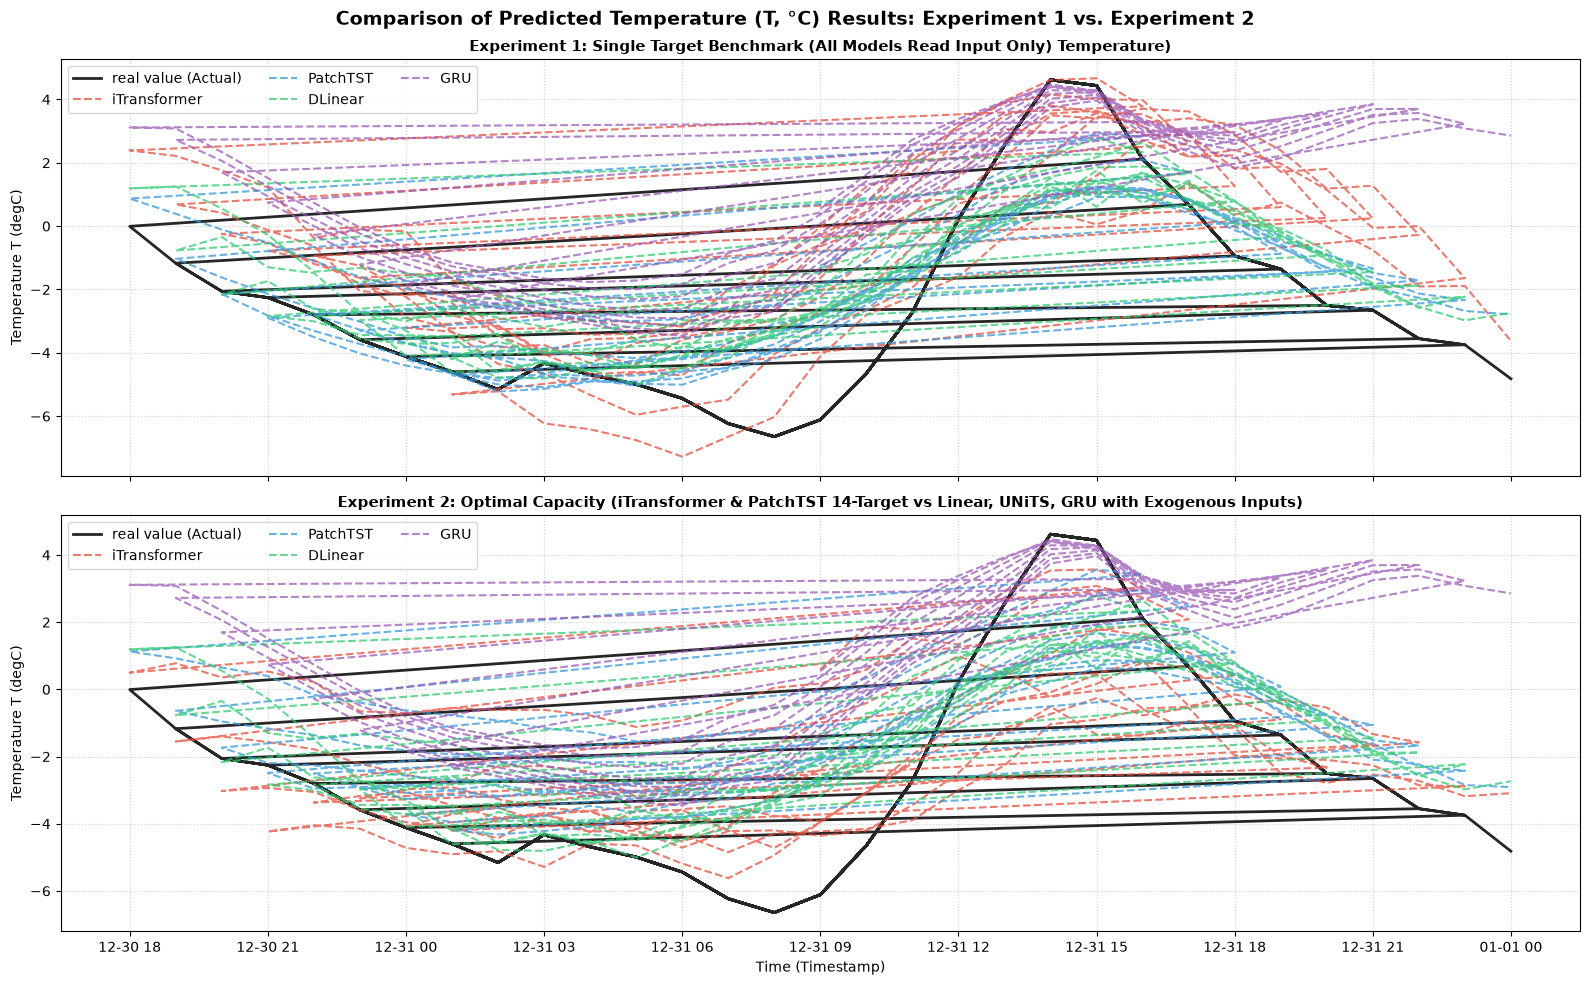

In [11]:
import matplotlib.pyplot as plt

# 1. Filter specifically for the target 'T (degC)' and select the last 200 timesteps for plotting.
plot_exp1 = cv_exp1[cv_exp1['unique_id'] == 'T (degC)'].tail(200)
plot_exp2 = cv_exp2[cv_exp2['unique_id'] == 'T (degC)'].tail(200)

# The colors are consistent for each model across both subplots.
colors = {
    'iTransformer': '#e74c3c',  # Red
    'PatchTST': '#3498db',  # Blue
    'DLinear': '#2ecc71',  # Green
    'NHiTS': '#f39c12',  # Orange
    'GRU': '#9b59b6',  # Puple
}

models = ['iTransformer', 'PatchTST', 'DLinear', 'NHiTS', 'GRU']

# 2. Create a Figure with 2 Vertical Subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- Subplot 1: Experiment 1 (Pure Single Target) ---
ax1.plot(
    plot_exp1['ds'],
    plot_exp1['y'],
    label='real value (Actual)',
    color='black',
    linewidth=2,
    alpha=0.85,
)

for model in models:
  if model in plot_exp1.columns:
    ax1.plot(
        plot_exp1['ds'],
        plot_exp1[model],
        label=model,
        color=colors[model],
        linestyle='--',
        alpha=0.75,
    )

ax1.set_title(
    'Experiment 1: Single Target Benchmark (All Models Read Input Only)'
    ' Temperature)',
    fontsize=11,
    fontweight='bold',
)
ax1.set_ylabel('Temperature T (degC)', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', ncol=3)

# --- Subplot 2: Experiment 2 (Optimal Capacity) ---
ax2.plot(
    plot_exp2['ds'],
    plot_exp2['y'],
    label='real value (Actual)',
    color='black',
    linewidth=2,
    alpha=0.85,
)

for model in models:
  if model in plot_exp2.columns:
    ax2.plot(
        plot_exp2['ds'],
        plot_exp2[model],
        label=model,
        color=colors[model],
        linestyle='--',
        alpha=0.75,
    )

ax2.set_title(
    'Experiment 2: Optimal Capacity (iTransformer & PatchTST 14-Target vs'
    ' Linear, UNiTS, GRU with Exogenous Inputs)',
    fontsize=11,
    fontweight='bold',
)
ax2.set_xlabel('Time (Timestamp)', fontsize=10)
ax2.set_ylabel('Temperature T (degC)', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', ncol=3)

# Layout adjustment & saving
plt.suptitle(
    'Comparison of Predicted Temperature (T, °C) Results: Experiment 1 vs. Experiment 2',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('Comparison of experiments 1 vs. 2 (temperature).png', dpi=300)
plt.show()

# **Calculating the percentage difference in the reduction of MAE and RMSE (performance improvement) from Experiment 1 to Experiment 2 for each model**

In [8]:
import pandas as pd
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse

MODEL_NAMES = ['iTransformer', 'PatchTST', 'DLinear', 'NHITS', 'GRU']

# 1. Calculate the specific evaluation of the 'T (degC)' target for both experiments.
eval_exp1 = evaluate(
    df=cv_exp1[cv_exp1['unique_id'] == 'T (degC)'],
    metrics=[mae, rmse],
    models=MODEL_NAMES,
)

eval_exp2 = evaluate(
    df=cv_exp2[cv_exp2['unique_id'] == 'T (degC)'],
    metrics=[mae, rmse],
    models=MODEL_NAMES,
)

# 2. DataFrame Structure Transformation (Model as Row Index)
df_exp1 = eval_exp1.groupby('metric')[MODEL_NAMES].mean().T
df_exp2 = eval_exp2.groupby('metric')[MODEL_NAMES].mean().T

# 3. Calculate the Percentage Increase
summary_df = pd.DataFrame(index=MODEL_NAMES)

# MAE
summary_df['MAE Exp1'] = df_exp1['mae']
summary_df['MAE Exp2'] = df_exp2['mae']
summary_df['Increasing MAE (%)'] = (
    (df_exp1['mae'] - df_exp2['mae']) / df_exp1['mae']
) * 100

# RMSE
summary_df['RMSE Exp1'] = df_exp1['rmse']
summary_df['RMSE Exp2'] = df_exp2['rmse']
summary_df['Increasing RMSE (%)'] = (
    (df_exp1['rmse'] - df_exp2['rmse']) / df_exp1['rmse']
) * 100

# 4. Format Output
summary_df = summary_df.round(3)

print('=== Performance Delta Analysis: Experiment 1 vs. Experiment 2 ===')
print(summary_df.to_string())

=== Performance Delta Analysis: Experiment 1 vs. Experiment 2 ===
              MAE Exp1  MAE Exp2  Increasing MAE (%)  RMSE Exp1  RMSE Exp2  Increasing RMSE (%)
iTransformer     2.356     2.297               2.484      2.784      2.743                1.486
PatchTST         1.990     2.202             -10.660      2.388      2.614               -9.459
DLinear          2.141     2.141               0.000      2.531      2.531                0.000
NHITS            2.562     2.562               0.000      3.084      3.084                0.000
GRU              3.069     3.069               0.000      3.474      3.474                0.000


# **taking 1 cutoff for all models in all experiment**

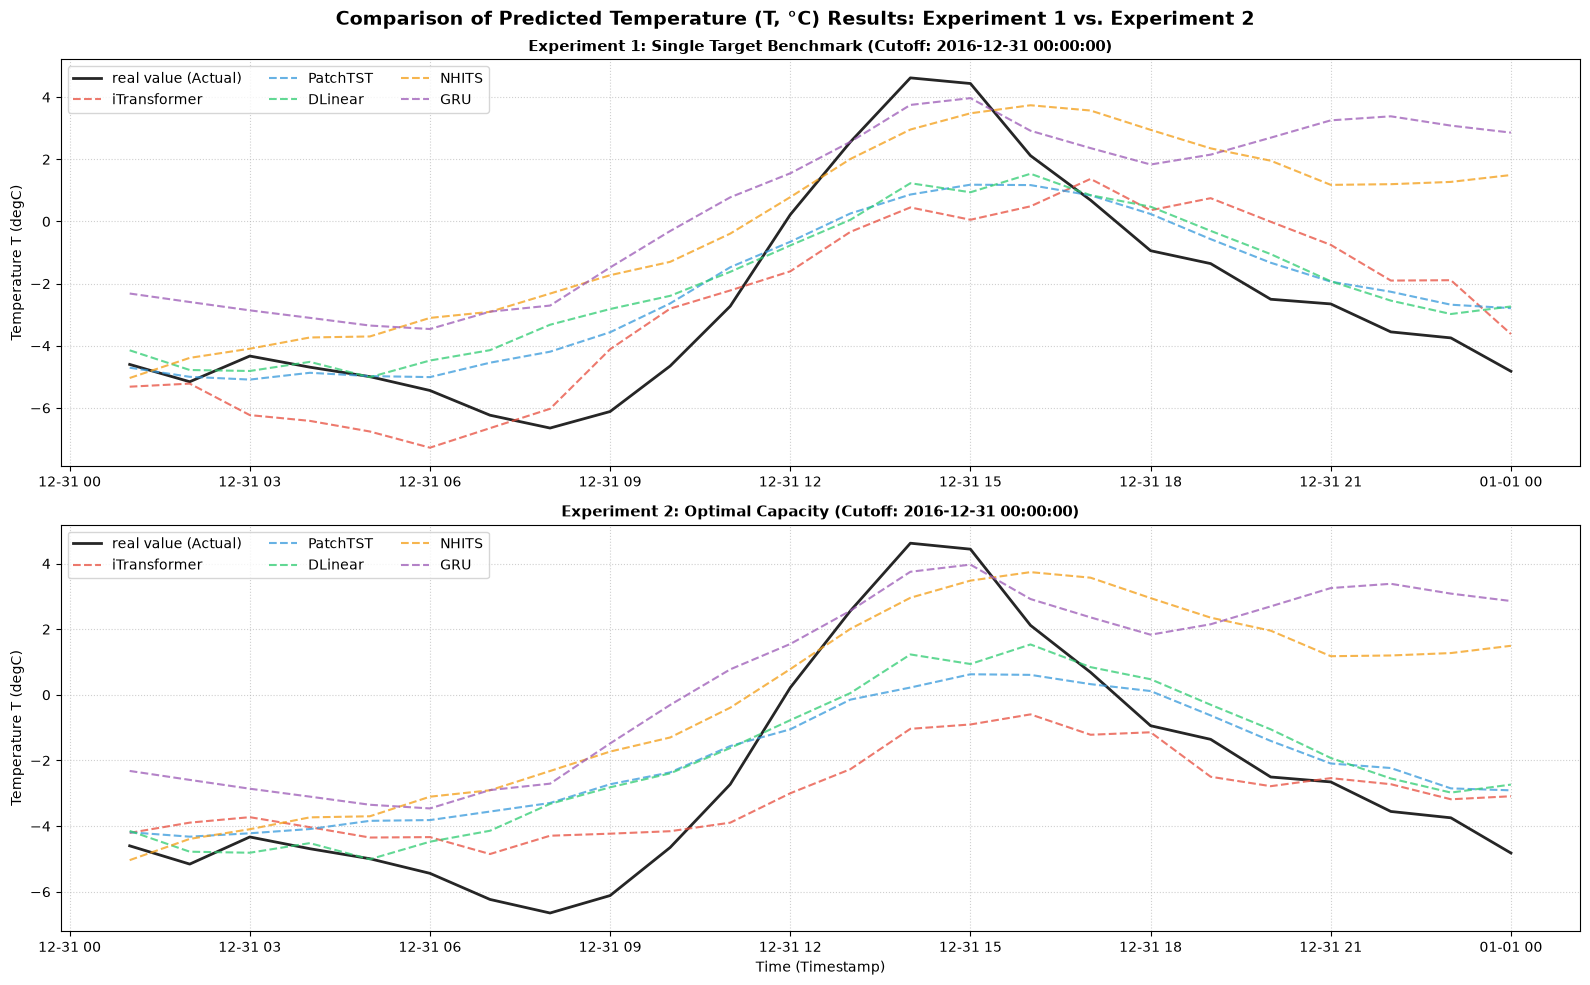

In [ ]:
import matplotlib.pyplot as plt

# 1. Ambil nilai cutoff terakhir dari masing-masing eksperimen
selected_cutoff_1 = cv_exp1['cutoff'].unique()[-1]
selected_cutoff_2 = cv_exp2['cutoff'].unique()[-1]

# 2. Filter khusus target 'T (degC)' DAN 1 cutoff tunggal
plot_exp1 = cv_exp1[
    (cv_exp1['unique_id'] == 'T (degC)')
    & (cv_exp1['cutoff'] == selected_cutoff_1)
]
plot_exp2 = cv_exp2[
    (cv_exp2['unique_id'] == 'T (degC)')
    & (cv_exp2['cutoff'] == selected_cutoff_2)
]

# Konsistensi warna model (menggunakan 'NHITS' huruf kapital semua)
colors = {
    'iTransformer': '#e74c3c',  # Red
    'PatchTST': '#3498db',  # Blue
    'DLinear': '#2ecc71',  # Green
    'NHITS': '#f39c12',  # Orange
    'GRU': '#9b59b6',  # Purple
}

models = ['iTransformer', 'PatchTST', 'DLinear', 'NHITS', 'GRU']

# 3. Buat Figure dengan 2 Subplot Vertikal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# --- Subplot 1: Experiment 1 (Single Target Benchmark) ---
ax1.plot(
    plot_exp1['ds'],
    plot_exp1['y'],
    label='real value (Actual)',
    color='black',
    linewidth=2,
    alpha=0.85,
)

for model in models:
  if model in plot_exp1.columns:
    ax1.plot(
        plot_exp1['ds'],
        plot_exp1[model],
        label=model,
        color=colors[model],
        linestyle='--',
        alpha=0.75,
    )

ax1.set_title(
    f'Experiment 1: Single Target Benchmark (Cutoff: {selected_cutoff_1})',
    fontsize=11,
    fontweight='bold',
)
ax1.set_ylabel('Temperature T (degC)', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', ncol=3)

# --- Subplot 2: Experiment 2 (Optimal Capacity) ---
ax2.plot(
    plot_exp2['ds'],
    plot_exp2['y'],
    label='real value (Actual)',
    color='black',
    linewidth=2,
    alpha=0.85,
)

for model in models:
  if model in plot_exp2.columns:
    ax2.plot(
        plot_exp2['ds'],
        plot_exp2[model],
        label=model,
        color=colors[model],
        linestyle='--',
        alpha=0.75,
    )

ax2.set_title(
    f'Experiment 2: Optimal Capacity (Cutoff: {selected_cutoff_2})',
    fontsize=11,
    fontweight='bold',
)
ax2.set_xlabel('Time (Timestamp)', fontsize=10)
ax2.set_ylabel('Temperature T (degC)', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', ncol=3)

# Judul Utama & Penyimpanan File
plt.suptitle(
    'Comparison of Predicted Temperature (T, °C) Results: Experiment 1 vs.'
    ' Experiment 2',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('Comparison of experiments 1 vs. 2 (temperature).png', dpi=300)
plt.show()